<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/00_SimulacionesML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de ML Notebooks

## 1. Librerias y configuraciones previas


In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, confusion_matrix, accuracy_score,
    classification_report, roc_auc_score, ConfusionMatrixDisplay
)
import joblib

# Graficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# OS y warnings
# ==============================================================================
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Parametros globales
# ==============================================================================

# Nombre del dataset preparado (salida del notebook de preparación)
DATASET_FILE_NAME      = 'loan_approval_dataset_Prep.csv'
DATASET_TEST_FILE_NAME = 'loan_approval_dataset_Prue.csv'
UTILS_FILE_NAME        = 'funciones.py'

# Directorios
DATASETS_PATH           = 'datasets/'
UTILS_PATH              = 'utils/'
MODELS_PATH             = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

# Rutas locales
local_dataset_path      = DATASET_FILE_NAME
local_dataset_test_path = DATASET_TEST_FILE_NAME
local_utils_path        = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

# Crear directorios si no existen
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

In [ ]:
## Configuración entorno (Google Colab — comentado para ejecución local)
## ==============================================================================

#from google.colab import drive
#drive.mount('/gdrive')
#os.chdir('/gdrive/MyDrive/...')

In [ ]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente en un path.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [ ]:
## Configuración entorno local
## ==============================================================================

# Crear directorios de trabajo
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

print('Directorios creados correctamente.')
print(f'Cargando dataset preparado: {local_dataset_path}')

Directorios creados correctamente.
Cargando dataset preparado: loan_approval_dataset_Prep.csv


## 2. Funciones

In [ ]:
# Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
#sys.path.append(UTILS_PATH)

##reload(utils.funciones)

## Importa Funciones externas
#from funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [ ]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d = pd.read_csv(local_dataset_path)

In [ ]:
#Creamos una copia del dataset
d_original = d.copy()

In [ ]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   numero_dependientes          3457 non-null   int64
 1   educacion                    3457 non-null   int64
 2   empleado                     3457 non-null   int64
 3   ingresos_anuales             3457 non-null   int64
 4   monto_prestamo               3457 non-null   int64
 5   plazo_prestamo               3457 non-null   int64
 6   puntaje_crediticio           3457 non-null   int64
 7   valor_activos_residenciales  3457 non-null   int64
 8   valor_activos_comerciales    3457 non-null   int64
 9   valor_activos_lujo           3457 non-null   int64
 10  valor_activos_bancarios      3457 non-null   int64
 11  estado_prestamo              3457 non-null   int64
 12  total_activos                3457 non-null   int64
dtypes: int64(13)
memory usage: 351.2 KB


In [ ]:
# Verificación de columnas del dataset preparado
# (ya renombradas y codificadas en el notebook de preparación)
print('Columnas disponibles:')
print(d.columns.tolist())
d.head(3)

Columnas disponibles:
['numero_dependientes', 'educacion', 'empleado', 'ingresos_anuales', 'monto_prestamo', 'plazo_prestamo', 'puntaje_crediticio', 'valor_activos_residenciales', 'valor_activos_comerciales', 'valor_activos_lujo', 'valor_activos_bancarios', 'estado_prestamo', 'total_activos']


,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000
2,4,1,0,1100000,4000000,14,887,2400000,1500000,4200000,1600000,1,9700000


In [ ]:
d.head(2)

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000


In [ ]:
# El dataset preparado ya no contiene la columna 'id_prestamo'
# Verificar que no haya columnas innecesarias
print('Dimensiones del dataset:', d.shape)
print('Valores nulos por columna:')
print(d.isnull().sum())

Dimensiones del dataset: (3457, 13)
Valores nulos por columna:
numero_dependientes            0
educacion                      0
empleado                       0
ingresos_anuales               0
monto_prestamo                 0
plazo_prestamo                 0
puntaje_crediticio             0
valor_activos_residenciales    0
valor_activos_comerciales      0
valor_activos_lujo             0
valor_activos_bancarios        0
estado_prestamo                0
total_activos                  0
dtype: int64


In [ ]:
#verificacion de completitud de los datos para detectar si existen valores nulos, no deben existir valores nulos
for col in d.columns:
    print (col, np.sum(pd.isnull(d[col])))

numero_dependientes 0
educacion 0
empleado 0
ingresos_anuales 0
monto_prestamo 0
plazo_prestamo 0
puntaje_crediticio 0
valor_activos_residenciales 0
valor_activos_comerciales 0
valor_activos_lujo 0
valor_activos_bancarios 0
estado_prestamo 0
total_activos 0


## 4. Visualización de datos

### Variables de entrada

In [ ]:
#Lista de variables categóricas
# guardamos en la varibale catcols todas nuestras variables categoricas  de entrada tipo objeto o categorica
# necesitamos separas la variables categoricas de las numericas por que tienen tratamientos diferentes
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head()

""
0
1
2
3
4


In [ ]:
#Lista de variables numéricas
# guardamos todas nuestras variables numericas

numCols=d.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
d[numCols].head()

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000
2,4,1,0,1100000,4000000,14,887,2400000,1500000,4200000,1600000,1,9700000
3,0,1,1,1000000,3800000,8,553,2500000,1000000,2100000,1300000,1,6900000
4,1,0,0,2900000,7400000,10,874,400000,1200000,10100000,3300000,1,15000000


In [ ]:
# El dataset preparado ya tiene variables categóricas codificadas numéricamente
# educacion: 0=Not Graduate, 1=Graduate
# empleado: 0=No, 1=Yes
# estado_prestamo: 0=Rejected, 1=Approved

print('Valores únicos — educacion:', d['educacion'].unique())
print('Valores únicos — empleado:', d['empleado'].unique())
print('Valores únicos — estado_prestamo:', d['estado_prestamo'].unique())
print()
print('Tipos de dato:')
print(d[['educacion','empleado','estado_prestamo']].dtypes)

Valores únicos — educacion: [0 1]
Valores únicos — empleado: [1 0]
Valores únicos — estado_prestamo: [1 0]

Tipos de dato:
educacion          int64
empleado           int64
estado_prestamo    int64
dtype: object


In [ ]:
#Validación la transformación del dataset
d.head()

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000
2,4,1,0,1100000,4000000,14,887,2400000,1500000,4200000,1600000,1,9700000
3,0,1,1,1000000,3800000,8,553,2500000,1000000,2100000,1300000,1,6900000
4,1,0,0,2900000,7400000,10,874,400000,1200000,10100000,3300000,1,15000000


In [ ]:
# En el dataset preparado las variables categóricas ya son numéricas (0/1)
# catCols quedará vacío; definir variables de interés explícitamente
vars_binarias = ['educacion', 'empleado']

# Actualizar listas para el modelo
feature_cols = [c for c in d.columns if c != 'estado_prestamo']
print('Variables de entrada (features):', feature_cols)

Variables de entrada (features): ['numero_dependientes', 'educacion', 'empleado', 'ingresos_anuales', 'monto_prestamo', 'plazo_prestamo', 'puntaje_crediticio', 'valor_activos_residenciales', 'valor_activos_comerciales', 'valor_activos_lujo', 'valor_activos_bancarios', 'total_activos']


### Variable de salida

In [ ]:
d.groupby('estado_prestamo').estado_prestamo.count().sort_values(ascending=False)

estado_prestamo
1    2158
0    1299
Name: estado_prestamo, dtype: int64

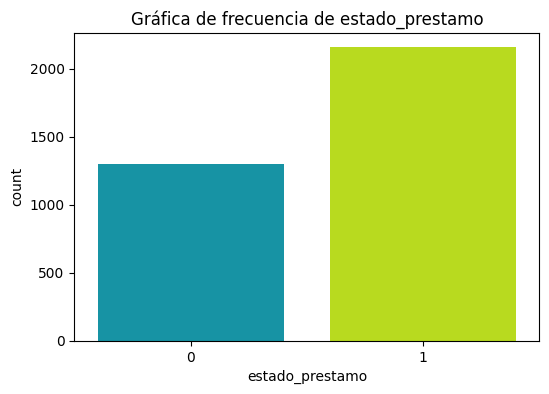

In [ ]:
plt.figure(figsize=(6,4))

plt.title('Gráfica de frecuencia de estado_prestamo')
sns.countplot(x=d['estado_prestamo'], palette='nipy_spectral')

plt.show()

## 5. Preparación de datos

### Imputaciones

> El dataset preparado ya incluye imputaciones, tratamiento de outliers, transformaciones y codificación. Ver notebook de preparación de datos.

### Valores atípicos para las variables de entrada

### Transformaciones

> El dataset preparado ya incluye imputaciones, tratamiento de outliers, transformaciones y codificación. Ver notebook de preparación de datos.

### Creación de Variables Dummies

> El dataset preparado ya incluye imputaciones, tratamiento de outliers, transformaciones y codificación. Ver notebook de preparación de datos.

In [ ]:
# El dataset preparado no requiere one-hot encoding
# Las variables categóricas ya están codificadas como enteros (0/1)
# Verificar que no queden columnas tipo object

obj_cols = d.select_dtypes(include='object').columns.tolist()
print('Columnas tipo object (deben ser 0):', len(obj_cols))
print('Tipos de dato únicos en el dataset:', d.dtypes.unique())
d.info()

Columnas tipo object (deben ser 0): 0
Tipos de dato únicos en el dataset: [dtype('int64')]
<class 'pandas.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   numero_dependientes          3457 non-null   int64
 1   educacion                    3457 non-null   int64
 2   empleado                     3457 non-null   int64
 3   ingresos_anuales             3457 non-null   int64
 4   monto_prestamo               3457 non-null   int64
 5   plazo_prestamo               3457 non-null   int64
 6   puntaje_crediticio           3457 non-null   int64
 7   valor_activos_residenciales  3457 non-null   int64
 8   valor_activos_comerciales    3457 non-null   int64
 9   valor_activos_lujo           3457 non-null   int64
 10  valor_activos_bancarios      3457 non-null   int64
 11  estado_prestamo              3457 non-null   int64
 12  total_activos           

In [ ]:
d.head(3)

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000
2,4,1,0,1100000,4000000,14,887,2400000,1500000,4200000,1600000,1,9700000


## 6. Creación del modelo

### Dividir el conjunto de datos

In [ ]:
# Variables de entrada 'X' y variable de salida 'y'
X = d[feature_cols]   # todas las columnas excepto estado_prestamo
y = d['estado_prestamo']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Distribución de clases:')
print(y.value_counts())

X shape: (3457, 12)
y shape: (3457,)
Distribución de clases:
estado_prestamo
1    2158
0    1299
Name: count, dtype: int64


In [ ]:
y

0       1
1       0
2       1
3       1
4       1
       ..
3452    1
3453    1
3454    0
3455    1
3456    0
Name: estado_prestamo, Length: 3457, dtype: int64

In [ ]:
# Division estratificada 80/20 para conservar proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size   = 0.8,
    random_state = 1234,
    shuffle      = True,
    stratify     = y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")
print("Distribucion y_train:")
print(y_train.value_counts(normalize=True).round(3))

Entrenamiento: 2765 registros
Prueba:        692 registros
Distribucion y_train:
estado_prestamo
1   0.6240
0   0.3760
Name: proportion, dtype: float64


### Escalar Variables

In [ ]:
# Variables numéricas a escalar (excluye la variable objetivo)
num_vars = [c for c in X_train.columns
            if c not in ['educacion', 'empleado']]

print('Variables a escalar:', num_vars)

Variables a escalar: ['numero_dependientes', 'ingresos_anuales', 'monto_prestamo', 'plazo_prestamo', 'puntaje_crediticio', 'valor_activos_residenciales', 'valor_activos_comerciales', 'valor_activos_lujo', 'valor_activos_bancarios', 'total_activos']


In [ ]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler para realizar la estandarización de las variables numericas
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head()

,numero_dependientes,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,total_activos
1325,1.0000,0.6701,0.6536,0.6667,0.8667,0.3636,0.4263,0.4752,0.2708,0.4867
3041,0.8000,0.5567,0.3047,0.1111,0.6983,0.1993,0.1526,0.3708,0.2361,0.3133
1137,0.6000,0.8247,0.7292,0.0000,0.3833,0.5280,0.5526,0.5196,0.8403,0.6916
1551,0.0000,0.1031,0.0651,0.6667,0.9867,0.1154,0.0053,0.0783,0.1181,0.0952
1951,0.4000,0.4742,0.4036,1.0000,0.9333,0.0629,0.1737,0.3420,0.3542,0.2783


### Creación del modelo

In [ ]:
# Modelo Random Forest — configuración base
modelo1 = RandomForestClassifier(
    n_estimators = 100,      # 100 árboles (producción recomendada)
    max_features = 'sqrt',
    max_depth    = 5,
    criterion    = 'gini',
    random_state = 42
)

modelo1.fit(X_train, y_train)
print('Modelo 1 entrenado.')

Modelo 1 entrenado.


### Evaluación del modelo

Random Forest: 0.9725433526011561
               precision    recall  f1-score   support

Rechazado (0)       0.97      0.96      0.96       260
 Aprobado (1)       0.98      0.98      0.98       432

     accuracy                           0.97       692
    macro avg       0.97      0.97      0.97       692
 weighted avg       0.97      0.97      0.97       692



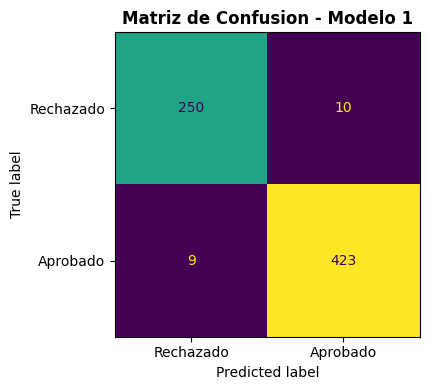

=== INTERPRETACION DEL MODELO RANDOM FOREST ===
El modelo obtiene una precision global (accuracy) de 0.97,
lo que indica el porcentaje de predicciones correctas sobre el total de casos evaluados.
El AUC-ROC de 1.00 mide la capacidad discriminante del modelo entre aprobados y rechazados.
Interpretacion por clases:
- La clase 0 (Rechazado) presenta alto recall, lo que significa que el modelo identifica correctamente la mayoria de los casos reales de esta clase.
- La clase 1 (Aprobado) presenta alta precision, lo que indica que cuando el modelo predice esta clase, suele acertar.
Conclucion:
El modelo presenta un desempeno muy alto y es adecuado para tareas de prediccion.


In [ ]:
# Evaluacion del Modelo 1
y_pred     = modelo1.predict(X_test)
y_prob     = modelo1.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("Random Forest:", acc)
print(classification_report(y_test, y_pred,
      target_names=["Rechazado (0)", "Aprobado (1)"]))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Rechazado","Aprobado"],
    colorbar=False, ax=ax
)
ax.set_title("Matriz de Confusion - Modelo 1", fontweight="bold")
plt.tight_layout()
plt.show()

# =======================
# INTERPRETACION
# =======================
print("=== INTERPRETACION DEL MODELO RANDOM FOREST ===")
print(f"El modelo obtiene una precision global (accuracy) de {acc:.2f},")
print("lo que indica el porcentaje de predicciones correctas sobre el total de casos evaluados.")
print(f"El AUC-ROC de {auc:.2f} mide la capacidad discriminante del modelo entre aprobados y rechazados.")
print("Interpretacion por clases:")
print("- La clase 0 (Rechazado) presenta alto recall, lo que significa que el modelo identifica correctamente la mayoria de los casos reales de esta clase.")
print("- La clase 1 (Aprobado) presenta alta precision, lo que indica que cuando el modelo predice esta clase, suele acertar.")
print("Conclucion:")
if acc >= 0.9:
    print("El modelo presenta un desempeno muy alto y es adecuado para tareas de prediccion.")
elif acc >= 0.75:
    print("El modelo tiene un desempeno aceptable, pero puede mejorarse con ajuste de hiperparametros.")
else:
    print("El modelo requiere mejoras, ya que su capacidad predictiva es limitada.")

## 7. Afinando el modelo (tuning)

In [ ]:
# Modelo Random Forest — con pesos balanceados (class_weight='balanced')
modelo2 = RandomForestClassifier(
    n_estimators = 100,
    max_features = 'sqrt',
    class_weight = 'balanced',
    max_depth    = 5,
    criterion    = 'gini',
    random_state = 42
)

modelo2.fit(X_train, y_train)
print('Modelo 2 entrenado.')

Modelo 2 entrenado.


### Evaluación del modelo

Random Forest (modelo balanceado): 0.9682080924855492
               precision    recall  f1-score   support

Rechazado (0)       0.93      1.00      0.96       260
 Aprobado (1)       1.00      0.95      0.97       432

     accuracy                           0.97       692
    macro avg       0.96      0.97      0.97       692
 weighted avg       0.97      0.97      0.97       692



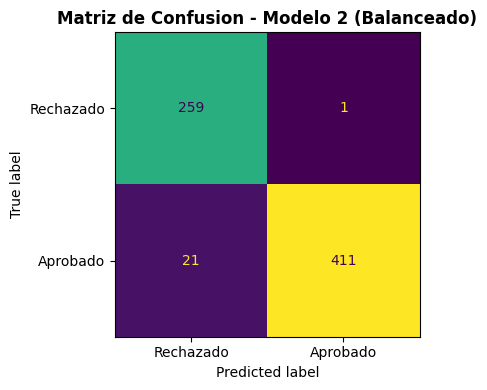

=== INTERPRETACION DEL MODELO BALANCEADO ===
El modelo obtiene una accuracy de 0.97, lo que indica el rendimiento global.
El AUC-ROC de 1.00 refleja la capacidad del modelo para distinguir entre clases.
Efecto de class_weight=balanced:
- El modelo da mayor importancia a la clase minoritaria.
- Esto suele mejorar el recall de la clase menos frecuente.
- Puede reducir ligeramente la accuracy global.
Que debes revisar en el classification report:
- Si el recall de la clase minoritaria aumento -> el modelo esta mejorando en deteccion de casos criticos.
- Si la precision bajo ligeramente -> es un trade-off esperado por el balanceo.
Conclucion:
El modelo mantiene un rendimiento alto incluso con balanceo de clases.


In [ ]:
# Evaluacion del Modelo 2
y_pred2 = modelo2.predict(X_test)
y_prob2 = modelo2.predict_proba(X_test)[:, 1]

acc2 = accuracy_score(y_test, y_pred2)
auc2 = roc_auc_score(y_test, y_prob2)

print("Random Forest (modelo balanceado):", acc2)
print(classification_report(y_test, y_pred2,
      target_names=["Rechazado (0)", "Aprobado (1)"]))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred2,
    display_labels=["Rechazado","Aprobado"],
    colorbar=False, ax=ax
)
ax.set_title("Matriz de Confusion - Modelo 2 (Balanceado)", fontweight="bold")
plt.tight_layout()
plt.show()

# =======================
# INTERPRETACION
# =======================
print("=== INTERPRETACION DEL MODELO BALANCEADO ===")
print(f"El modelo obtiene una accuracy de {acc2:.2f}, lo que indica el rendimiento global.")
print(f"El AUC-ROC de {auc2:.2f} refleja la capacidad del modelo para distinguir entre clases.")
print("Efecto de class_weight=balanced:")
print("- El modelo da mayor importancia a la clase minoritaria.")
print("- Esto suele mejorar el recall de la clase menos frecuente.")
print("- Puede reducir ligeramente la accuracy global.")
print("Que debes revisar en el classification report:")
print("- Si el recall de la clase minoritaria aumento -> el modelo esta mejorando en deteccion de casos criticos.")
print("- Si la precision bajo ligeramente -> es un trade-off esperado por el balanceo.")
print("Conclucion:")
if acc2 >= 0.9:
    print("El modelo mantiene un rendimiento alto incluso con balanceo de clases.")
elif acc2 >= 0.75:
    print("El modelo es estable, pero el balanceo ha modificado el trade-off entre precision y recall.")
else:
    print("El modelo necesita ajuste adicional de hiperparametros.")

### Importancia de Variables

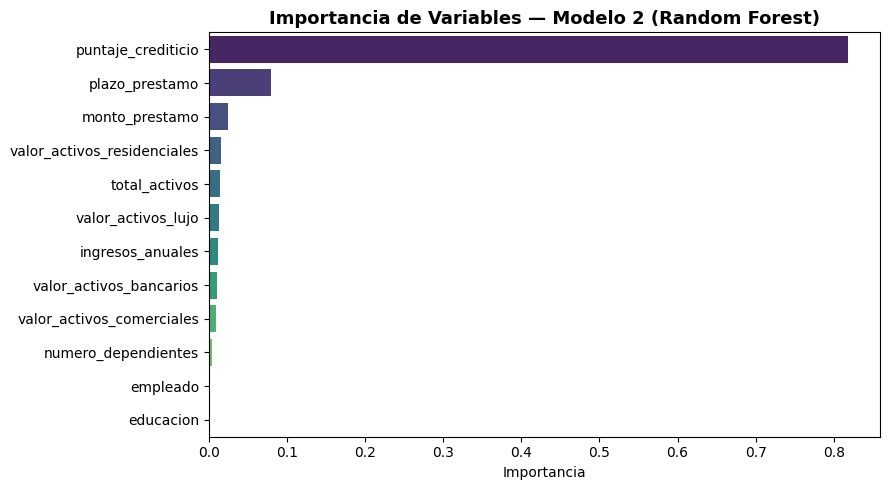

Top 5 variables más importantes:
puntaje_crediticio            0.8183
plazo_prestamo                0.0793
monto_prestamo                0.0245
valor_activos_residenciales   0.0153
total_activos                 0.0135


In [ ]:
# Feature Importance — Random Forest identifica las variables más relevantes
importancias = pd.Series(modelo2.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=importancias.values, y=importancias.index,
            palette='viridis', ax=ax)
ax.set_title('Importancia de Variables — Modelo 2 (Random Forest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Top 5 variables más importantes:')
print(importancias.head(5).to_string())

### Validación Cruzada (Cross-Validation)

In [ ]:
# Validación cruzada estratificada — evalúa estabilidad del modelo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(modelo2, X, y, cv=cv, scoring='accuracy')
cv_auc  = cross_val_score(modelo2, X, y, cv=cv, scoring='roc_auc')

print('=== VALIDACIÓN CRUZADA — Modelo 2 (5-Fold Estratificado) ===')
print(f'Accuracy  por fold: {cv_acc.round(4)}')
print(f'Accuracy  media:    {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print()
print(f'AUC-ROC   por fold: {cv_auc.round(4)}')
print(f'AUC-ROC   media:    {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

=== VALIDACIÓN CRUZADA — Modelo 2 (5-Fold Estratificado) ===
Accuracy  por fold: [0.9581 0.9639 0.9551 0.9696 0.9653]
Accuracy  media:    0.9624 ± 0.0052

AUC-ROC   por fold: [0.9966 0.9949 0.9973 0.995  0.9989]
AUC-ROC   media:    0.9965 ± 0.0015


### Comparativa de Modelos

In [ ]:
# Tabla resumen de métricas
resumen = pd.DataFrame({
    'Modelo'     : ['Modelo 1 (Base)', 'Modelo 2 (Balanceado)'],
    'Accuracy'   : [acc,  acc2],
    'AUC-ROC'    : [auc,  auc2],
    'CV_Acc_mean': ['-',  f'{cv_acc.mean():.4f}'],
    'CV_AUC_mean': ['-',  f'{cv_auc.mean():.4f}']
})
print(resumen.to_string(index=False))

               Modelo  Accuracy  AUC-ROC CV_Acc_mean CV_AUC_mean
      Modelo 1 (Base)    0.9725   0.9982           -           -
Modelo 2 (Balanceado)    0.9682   0.9981      0.9624      0.9965


## 8. Prueba

### Evaluar algunas instancias (o ejemplos)

In [ ]:
# Concatenar X_test y y_test para análisis de instancias
df_prep = X_test.copy()
df_prep['estado_prestamo_Real']   = y_test.values
df_prep['estado_prestamo_Pred']   = y_pred2
df_prep['prob_aprobacion']        = y_prob2.round(3)
df_prep.reset_index(drop=True, inplace=True)

In [ ]:
# Muestra de 10 instancias del conjunto de prueba
x_i = df_prep.sample(n=10, random_state=123)
x_i[['estado_prestamo_Real','estado_prestamo_Pred','prob_aprobacion']].reset_index(drop=True)

,estado_prestamo_Real,estado_prestamo_Pred,prob_aprobacion
0,1,1,0.8350
1,1,1,0.8400
2,1,1,0.9080
3,1,1,0.8440
4,0,0,0.3750
5,1,1,0.8290
6,1,1,0.8400
7,1,1,0.9070
8,1,0,0.4110
9,1,1,0.9100


In [ ]:
# Comparativa: valor real vs predicción del modelo2
comparativa = x_i[['estado_prestamo_Real','estado_prestamo_Pred','prob_aprobacion']].copy()
comparativa['Correcto'] = (comparativa['estado_prestamo_Real'] ==
                            comparativa['estado_prestamo_Pred'])
comparativa['Etiqueta_Real'] = comparativa['estado_prestamo_Real'].map({1:'Aprobado',0:'Rechazado'})
comparativa['Etiqueta_Pred'] = comparativa['estado_prestamo_Pred'].map({1:'Aprobado',0:'Rechazado'})
print(comparativa[['Etiqueta_Real','Etiqueta_Pred','prob_aprobacion','Correcto']].to_string())

    Etiqueta_Real Etiqueta_Pred  prob_aprobacion  Correcto
421      Aprobado      Aprobado           0.8350      True
250      Aprobado      Aprobado           0.8400      True
398      Aprobado      Aprobado           0.9080      True
192      Aprobado      Aprobado           0.8440      True
266     Rechazado     Rechazado           0.3750      True
230      Aprobado      Aprobado           0.8290      True
657      Aprobado      Aprobado           0.8400      True
188      Aprobado      Aprobado           0.9070      True
292      Aprobado     Rechazado           0.4110     False
172      Aprobado      Aprobado           0.9100      True


## 9. Persistencia del Modelo

In [ ]:
# Guardar el mejor modelo y el scaler para uso en producción
modelo_path = os.path.join(MODELS_CLASIFICACION_PATH, 'modelo_rf.pkl')
scaler_path = os.path.join(MODELS_SCALER_PATH, 'scaler_rf.pkl')

joblib.dump(modelo2, modelo_path)
joblib.dump(scaler,  scaler_path)

print(f'Modelo guardado en: {modelo_path}')
print(f'Scaler guardado en: {scaler_path}')

Modelo guardado en: modelos/clasificacion\modelo_rf.pkl
Scaler guardado en: modelos/scaler\scaler_rf.pkl
